# Library
This block is used to import all libraries that will be needed for 
1. Data Preprocessing
2. Feature Engineering
3. Embedding
4. Graph Preparation
5. Visualization
6. Scaling
7. Saving artifacts

We also set global seed to make ensure reproducibility for the method later

In [4]:
# Core libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import emoji
import pickle
from collections import Counter

# Machine learning + preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

# Embedding model
from sentence_transformers import SentenceTransformer

# Visualization
from wordcloud import WordCloud

# Set global seeds for reproducibility
import torch
import random
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)


import warnings
warnings.filterwarnings("ignore")

# Our Dataset

We load the Amazon Fashion JSONL review dataset.
Each line in this file is a dictionary with fields like:

- rating
- title
- text
- images
- asin
- parent_asin
- user_id
- timestamp
- helpful_vote
- verified purchase

This dataset may contain missing values or inconsistent entries, so loading with basic checks is important.

In [5]:
df = pd.read_json("Amazon_Fashion.jsonl", lines=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500939 entries, 0 to 2500938
Data columns (total 10 columns):
 #   Column             Dtype         
---  ------             -----         
 0   rating             int64         
 1   title              object        
 2   text               object        
 3   images             object        
 4   asin               object        
 5   parent_asin        object        
 6   user_id            object        
 7   timestamp          datetime64[ns]
 8   helpful_vote       int64         
 9   verified_purchase  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(6)
memory usage: 174.1+ MB


In [6]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Pretty locket,I think this locket is really pretty. The insi...,[],B00LOPVX74,B00LOPVX74,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ,2020-01-09 00:06:34.489,3,True
1,5,A,Great,[],B07B4JXK8D,B07B4JXK8D,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-20 01:04:06.701,0,True
2,2,Two Stars,One of the stones fell out within the first 2 ...,[],B007ZSEQ4Q,B007ZSEQ4Q,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,2015-05-23 01:33:48.000,3,True
3,1,Won’t buy again,Crappy socks. Money wasted. Bought to wear wit...,[],B07F2BTFS9,B07F2BTFS9,AFVNEEPDEIH5SPUN5BWC6NKL3WNQ,2018-12-31 20:57:27.095,2,True
4,5,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,[],B00PKRFU4O,B00XESJTDE,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2015-08-13 14:29:26.000,0,True


In [7]:
df.isna().sum()

rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

In [8]:
df.drop(columns=['images'], inplace=True)

Our data consists of 2.5 million reviews data from Amazon dataset, particularly in fashion dataset. This domain is chosen because people really rely on the reviews of other person since they can't feel the item that they wanna buy directly. There is no missing data in the dataset, however, we not gonna use the images column at all for this fake review detection

# Preprocessing

## K-Core Filtering

K-Core filtering is needed to done in review dataset with some purpose:
- To reduce sparsity of the data, because there are much data that only have 1 reviews or reviewer that only have reviewed 1 product
- Fairer evaluation, especially if using GNN. History or neighbor is needed to make our model learn
- Stability and reproducibility for the data
- Computationally more efficient since we have less data

As for this data, we will perform a K-Core filtering with 3-2-Core rule where 
- Each item need to have 3 reviews each, and
- Each user need to have 2 reviews each

This is done incrementally until the requirements met

In [9]:
def k_core_filtering(df, k_items=3, k_users=2, verbose=True):
    iteration = 0
    df_filtered = df.copy()

    while True:
        iteration += 1
        if verbose:
            print(f"\nIteration {iteration}: {len(df_filtered)} rows")

        before = len(df_filtered)
        
        item_mask = df_filtered['asin'].map(df_filtered['asin'].value_counts()) >= k_items
        df_filtered = df_filtered[item_mask]

        # Filter users
        user_mask = df_filtered['user_id'].map(df_filtered['user_id'].value_counts()) >= k_users
        df_filtered = df_filtered[user_mask]

        after = len(df_filtered)
        if verbose:
            print(f"Remaining rows: {after} (filtered {before - after})")

        if before == after:
            break

    return df_filtered.reset_index(drop=True)

data = k_core_filtering(df)
print(f"Users: {data.user_id.nunique()}, Items: {data.asin.nunique()}, Reviews: {len(data)}")



Iteration 1: 2500939 rows
Remaining rows: 398409 (filtered 2102530)

Iteration 2: 398409 rows
Remaining rows: 211865 (filtered 186544)

Iteration 3: 211865 rows
Remaining rows: 180792 (filtered 31073)

Iteration 4: 180792 rows
Remaining rows: 172310 (filtered 8482)

Iteration 5: 172310 rows
Remaining rows: 169845 (filtered 2465)

Iteration 6: 169845 rows
Remaining rows: 169091 (filtered 754)

Iteration 7: 169091 rows
Remaining rows: 168848 (filtered 243)

Iteration 8: 168848 rows
Remaining rows: 168770 (filtered 78)

Iteration 9: 168770 rows
Remaining rows: 168738 (filtered 32)

Iteration 10: 168738 rows
Remaining rows: 168728 (filtered 10)

Iteration 11: 168728 rows
Remaining rows: 168728 (filtered 0)
Users: 69587, Items: 29282, Reviews: 168728


After K-Core filtering we able to get 168 thousands of data. Meaning that we can reduce the data to be under 10% of the original data, removing so many noise from the data and alongside with that reducing computational cost needed for another process

## Timestamp Cleaning and Text Concatenation

We want clean inputs for:

- embedding
- time-based features
- duplicate detection

Steps:

- Convert timestamp to datetime
- Remove rows with invalid timestamps
- Combine title + text
- Ensure no NaN appears

In [10]:
data["timestamp"] = pd.to_datetime(data["timestamp"], errors="coerce")
data = data.dropna(subset=["timestamp"]).reset_index(drop=True)

# Fill missing title/text before combining
data["title"] = data["title"].fillna("")
data["text"] = data["text"].fillna("")

# Combine into full_text
data["full_text"] = (data["title"] + " " + data["text"]).str.strip()

## Text Cleaning

The cleaning function:

- lowercases
- removes URLs/emails
- normalizes repeated characters
- removes unwanted characters
- cleans whitespace

This improves embedding stability.

In [11]:
def clean_review(text: str) -> str:
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " <URL> ", text) # normalize urls
    text = re.sub(r"\S+@\S+", " <EMAIL> ", text) # normalize emails
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)  # normalize "soooo" -> "soo"
    text = re.sub(r"[^\w\s\.,!?'\u00A0-\uFFFF]", " ", text) # renove special chars except punctuation
    text = re.sub(r"\s+", " ", text).strip() # remove extra space
    return text

data["full_text"] = data["full_text"].apply(clean_review)

## Sentence Embedding

We embed the cleaned review text using XLM-RoBERTa-based paraphrase model. This step needed to be done to change the text data into numerical values that can be processed by another methods and be put into HGNN

XLM Roberta is used because in many paper, XLM-R is used and have a great performance

In [12]:
MODEL_NAME = "sentence-transformers/paraphrase-xlm-r-multilingual-v1"
embedding_model = SentenceTransformer(MODEL_NAME)

texts = data["full_text"].tolist()

# Batch size to use for embedding making it compute efficient
batch_size = 256  

text_embs = embedding_model.encode(
    texts,
    batch_size=batch_size,
    convert_to_numpy=True,
    show_progress_bar=True
)

Batches:   0%|          | 0/660 [00:00<?, ?it/s]

# Feature Engineering

## Review Level Feature Engineering

We create review-level features:

- length
- duplicate count
- log helpfulness
- verified purchase
- cyclical time features

This create more feature that our model would be able to recognize and differentiate the genuine data and anomaly spam data

### Duplicates Feature

Duplicate text are used to see if there are any pattern on the attacker behavior by text.

In [13]:
data["review_length"] = data["full_text"].apply(lambda x: len(x.split()))

# Duplicate detection using full_text
fulltext_counts = data["full_text"].value_counts()
data["dup_count"] = data["full_text"].map(fulltext_counts)
data["is_duplicate"] = (data["dup_count"] > 1).astype(int)

### Helpfulness Logarithmic

Helpful vote of a review can be a signal where people think that the review are genuine because they actually seems good and can help a lot of the future buyer

In [14]:
# Log transformed helpfulness
data["log_helpful"] = np.log1p(data["helpful_vote"])

### Verified purchase bool

Verified purchase can show if someone is actually buying the item before doing a review or not. This can make the review seems to be genuine because they actually feel how the item affect their experience

In [15]:
# Verified purchase
data["verified_int"] = data["verified_purchase"].astype(int)

### Cyclical time

We can see at which time by day and hour, when the attacker send their attacks of spam comments towards the product in Amazon Product reviews

In [16]:
# Cyclical time
data["day"] = data["timestamp"].dt.dayofyear
data["hour"] = data["timestamp"].dt.hour
data["sin_day"] = np.sin(2*np.pi*data["day"]/365)
data["cos_day"] = np.cos(2*np.pi*data["day"]/365)
data["sin_hour"] = np.sin(2*np.pi*data["hour"]/24)
data["cos_hour"] = np.cos(2*np.pi*data["hour"]/24)

## User-Level Behavioral Features

We compute:

- review count
- rating stats
- duplicate ratio
- burstiness
- entropy
- text similarity

In [17]:
user_stats = data.groupby("user_id").agg(
    n_reviews_user=("rating","count"),
    avg_rating_user=("rating","mean"),
    std_rating_user=("rating","std"),
    frac_verified_user=("verified_int","mean"),
    avg_len_user=("review_length","mean"),
    dup_ratio_user=("is_duplicate","mean")
).reset_index()

### Date Grouping and burstiness

We make it as number of reviews per day to show how many reviews per day does the user make

In [18]:
data["date"] = data["timestamp"].dt.date
user_daily = data.groupby(["user_id", "date"]).size().reset_index(name="reviews_per_day")

In [19]:
user_burst = user_daily.groupby("user_id")["reviews_per_day"].max().reset_index()
user_burst.rename(columns={"reviews_per_day": "max_reviews_per_day"}, inplace=True)

### Entropy

Entropy here is a measure of how spread out or how random a user’s review activity is across days.
Entropy tells us:

Does the user post reviews evenly across many days?
--> High entropy (looks like normal human behavior).

Does the user dump all reviews on one or very few days?
--> Low entropy (spam-like behavior / bots / paid reviewers).

In [20]:
def entropy(arr):
    probs = arr / arr.sum()
    return -np.sum(probs * np.log(probs + 1e-10))

user_entropy = user_daily.groupby("user_id")["reviews_per_day"].apply(entropy).reset_index()
user_entropy.rename(columns={"reviews_per_day": "day_entropy"}, inplace=True)

### Text Similarity 

In [21]:
similarities = []
LIMIT = 150  # to avoid O(n^2)

for uid, group in data.groupby("user_id"):
    n = len(group)
    if n > 1 and n <= LIMIT:
        embs = text_embs[group.index]
        sim_matrix = cosine_similarity(embs)
        upper = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]
        avg_sim = upper.mean()
    else:
        avg_sim = 0
    similarities.append((uid, avg_sim))

user_sim = pd.DataFrame(similarities, columns=["user_id","avg_text_sim"])

### Merge all user stats

In [22]:
user_stats = (
    user_stats
    .merge(user_burst, on="user_id", how="left")
    .merge(user_entropy, on="user_id", how="left")
    .merge(user_sim, on="user_id", how="left")
)
user_stats.fillna(0, inplace=True)

print("User-level features created with shape:", user_stats.shape)

User-level features created with shape: (69587, 10)


## Item Stats Feature

In [23]:
item_stats = data.groupby("asin").agg(
    n_reviews_item=("rating","count"),
    avg_rating_item=("rating","mean"),
    std_rating_item=("rating","std"),
    dup_ratio_item=("is_duplicate","mean")
).reset_index()

item_degree = data.groupby("asin")["user_id"].nunique().reset_index()
item_degree.rename(columns={"user_id": "n_unique_users"}, inplace=True)

item_stats = item_stats.merge(item_degree, on="asin", how="left")
item_stats.fillna(0, inplace=True)

print("Item-level features created with shape:", item_stats.shape)

Item-level features created with shape: (29282, 6)


## Graph Compatibility Features

These features will later be used in the heterogeneous graph model (SL-GAD + HGNN).
We compute:

- user degree
- item degree
- local density

In [24]:
user_degree = data.groupby("user_id")["asin"].nunique().reset_index()
user_degree.rename(columns={"asin": "n_unique_items"}, inplace=True)

item_degree = data.groupby("asin")["user_id"].nunique().reset_index()
item_degree.rename(columns={"user_id": "n_unique_users"}, inplace=True)

In [25]:
data["user_degree"] = data["user_id"].map(user_degree.set_index("user_id")["n_unique_items"])
data["item_degree"] = data["asin"].map(item_degree.set_index("asin")["n_unique_users"])

In [26]:
data["local_density"] = np.log1p(data["dup_count"]) / (data["user_degree"] * data["item_degree"] + 1e-5)

print("Graph-style neighborhood metrics created")

Graph-style neighborhood metrics created


## Scaling and Review Feature Matrix

In [27]:
scaler = StandardScaler()
numeric_cols = [
    "rating", "review_length", "log_helpful", "verified_int", "dup_count"
]

In [28]:
data_raw_numeric = data[numeric_cols].copy()
data_raw_numeric.head()

,rating,review_length,log_helpful,verified_int,dup_count
0,5,111,0.0,0,1
1,5,105,0.0,0,1
2,4,103,0.0,0,1
3,5,76,0.0,0,1
4,3,92,0.0,0,1


In [29]:
data_scaled = pd.DataFrame(scaler.fit_transform(data_raw_numeric), columns=[f"{c}_scaled" for c in numeric_cols])
data_scaled.head()

,rating_scaled,review_length_scaled,log_helpful_scaled,verified_int_scaled,dup_count_scaled
0,0.701344,1.640917,-0.434521,-2.772064,-0.143743
1,0.701344,1.511252,-0.434521,-2.772064,-0.143743
2,-0.066018,1.468030,-0.434521,-2.772064,-0.143743
3,0.701344,0.884536,-0.434521,-2.772064,-0.143743
4,-0.833379,1.230310,-0.434521,-2.772064,-0.143743


In [30]:
for col in data_scaled.columns:
    data[col] = data_scaled[col]

In [31]:
review_features = np.hstack([
    text_embs,
    data[
        [f"{c}_scaled" for c in numeric_cols] +
        ["sin_day","cos_day","sin_hour","cos_hour"]
    ].values
])

In [32]:
print("Review feature matrix shape:", review_features.shape)

Review feature matrix shape: (168728, 777)


# NFS Score

## Helper Functions

In [33]:
def entropy(p: np.ndarray) -> float:
    """
    Compute Shannon entropy for a probability distribution p.
    p is assumed to be non-negative and will be filtered for > 0.
    """
    p = p[p > 0]
    if len(p) == 0:
        return 0.0
    return -np.sum(p * np.log(p + 1e-12))

def kl_div(p: np.ndarray, q: np.ndarray) -> float:
    """
    Compute KL divergence KL(p || q) for two discrete distributions.
    Small eps added for numerical stability.
    """
    p = p + 1e-12
    q = q + 1e-12
    return np.sum(p * np.log(p / q))

## Global Reference Distribution

Global reference distribution to get how many reviews each user have and how many is a rating appear in the dataset

In [34]:
# Global user review counts (degree of users across all products)
user_review_counts = data.groupby("user_id").size()

# Distribution over "how many reviews users have" (global degree distribution)
global_deg = user_review_counts.value_counts(normalize=True).sort_index().values

# Global rating distribution (e.g., overall 1–5 star frequencies)
global_rating_dist = data["rating"].value_counts(normalize=True).sort_index().values

In [35]:
print("global_deg length:", len(global_deg))
print("global_rating_dist length:", len(global_rating_dist))

global_deg length: 47
global_rating_dist length: 5


## Per-product Statistics

In [36]:
product_stats = []

for asin, group in data.groupby("asin"):
    
    #! Degree Distribution inside of a product
    #? How many reviews per user this product has.
    user_counts = group['user_id'].value_counts()
    
    #? Distribution of user review counts for this product
    deg_dist = user_counts.value_counts(normalize=True).sort_index().values
    
    #! Rating Distribution inside of a product
    rating_dist = group["rating"].value_counts(normalize=True).sort_index().values
    
    # Entropies
    H_deg = entropy(deg_dist)
    H_pr = entropy(rating_dist)
    
    # Pad local vectors to match global vectors (for KL)
    # Degree distribution
    if len(deg_dist) < len(global_deg):
        g1 = np.pad(deg_dist, (0, len(global_deg) - len(deg_dist)), constant_values=0)
    else:
        g1 = deg_dist[:len(global_deg)]

    # Rating distribution
    if len(rating_dist) < len(global_rating_dist):
        g2 = np.pad(rating_dist, (0, len(global_rating_dist) - len(rating_dist)), constant_values=0)
    else:
        g2 = rating_dist[:len(global_rating_dist)]
        
    KL_deg = kl_div(g1, global_deg)
    KL_pr = kl_div(g2, global_rating_dist)

    product_stats.append([asin, H_deg, H_pr, KL_deg, KL_pr])
    
product_df = pd.DataFrame(product_stats, columns=["asin", "H_deg", "H_pr", "KL_deg", "KL_pr"])
print("✅ Product-level entropy and KL stats computed:", product_df.shape)

✅ Product-level entropy and KL stats computed: (29282, 5)


## Normalization and NFS-Score

In [37]:
scaler_nfs = MinMaxScaler()
product_df[["H_deg_n", "H_pr_n", "KL_deg_n", "KL_pr_n"]] = scaler_nfs.fit_transform(product_df[["H_deg", "H_pr", "KL_deg", "KL_pr"]])

In [38]:
# NFS: 1 - distance from origin in normalized space
# Intuition: small entropies & large divergences will shape this geometry.
product_df["NFS"] = 1- np.sqrt(
    (
        product_df["H_deg_n"]**2 +
        product_df["H_pr_n"]**2 +
        product_df["KL_deg_n"]**2 +
        product_df["KL_pr_n"]**2
    ) / 4.0
)

In [39]:
product_df.sort_values("NFS", ascending=False).head(10)

,asin,H_deg,H_pr,KL_deg,KL_pr,H_deg_n,H_pr_n,KL_deg_n,KL_pr_n,NFS
11482,B01DY3RSP4,1.242508e-01,0.712962,0.164652,0.146476,0.100004,0.442988,0.132440,0.055202,0.761868
7213,B012SGXOAQ,1.679441e-01,0.745740,0.143913,0.163758,0.135171,0.463354,0.111051,0.061845,0.750438
1635,B00B79ZAAS,3.061929e-01,0.708060,0.085544,0.153126,0.246442,0.439942,0.050851,0.057758,0.744949
367,B003V5HLG2,1.390608e-01,0.787640,0.157314,0.118147,0.111924,0.489388,0.124872,0.044314,0.740392
236,B002HU27UW,1.627648e-01,0.793107,0.151887,0.109281,0.131003,0.492785,0.119275,0.040907,0.737370
1341,B0093OIA3I,1.326914e-01,0.800193,0.160431,0.103629,0.106798,0.497188,0.128087,0.038735,0.737080
22360,B07C4NXXKV,1.584106e-01,0.804507,0.148204,0.103778,0.127498,0.499868,0.115477,0.038792,0.734970
57,B000FIS5U4,1.163375e-01,0.817479,0.168704,0.093798,0.093635,0.507928,0.136619,0.034956,0.732304
14337,B01K4WHD9Y,-1.000089e-12,0.793533,0.241080,0.118056,0.000000,0.493050,0.211266,0.044279,0.730885
4248,B00NALN81Y,9.962339e-02,0.851440,0.177567,0.080315,0.080183,0.529029,0.145761,0.029774,0.722316


# HISN Selection based on NFS

In [40]:
top_q = 0.08
nfs_threshold = product_df["NFS"].quantile(top_q)

In [41]:
target_asins = product_df[product_df["NFS"] <= nfs_threshold]["asin"]
print(f"Selected {len(target_asins)} target products out of {data['asin'].nunique()} total.")

Selected 2462 target products out of 29282 total.


In [42]:
target_data = data[data["asin"].isin(target_asins)].copy()
print("HISN base dataset shape:", target_data.shape)

HISN base dataset shape: (8832, 30)


In [43]:
coverage = len(target_data) / len(data)
print(f"{coverage*100:.2f}% of all reviews belong to NFS-selected products.")

5.23% of all reviews belong to NFS-selected products.


In [44]:
print("Users:", target_data["user_id"].nunique())
print("Items:", target_data["asin"].nunique())
print("Reviews (edges):", len(target_data))

Users: 5352
Items: 2462
Reviews (edges): 8832


In [45]:
avg_reviews_per_user = len(target_data) / target_data["user_id"].nunique()
avg_reviews_per_item = len(target_data) / target_data["asin"].nunique()

print(f"Avg reviews per user (HISN base): {avg_reviews_per_user:.2f}")
print(f"Avg reviews per item (HISN base): {avg_reviews_per_item:.2f}")

Avg reviews per user (HISN base): 1.65
Avg reviews per item (HISN base): 3.59


## Filter One-Shot users inside HISN

In [46]:
user_counts_hisn = target_data["user_id"].value_counts()
active_users = user_counts_hisn[user_counts_hisn >= 2].index
len(active_users)

2755

In [47]:
filtered_data = target_data[target_data["user_id"].isin(active_users)].copy()

In [48]:
print("\nAfter removing 1-review users inside HISN:")
print("Users:", filtered_data["user_id"].nunique())
print("Items:", filtered_data["asin"].nunique())
print("Reviews:", len(filtered_data))


After removing 1-review users inside HISN:
Users: 2755
Items: 2462
Reviews: 6235


## Expand HISN Neighborhood

In [49]:
target_users = filtered_data["user_id"].unique()
expanded_data = data[data["user_id"].isin(target_users)].copy()

print("\nAfter expanding to all reviews of HISN users:")
print("Users:", expanded_data["user_id"].nunique())
print("Items:", expanded_data["asin"].nunique())
print("Reviews:", len(expanded_data))


After expanding to all reviews of HISN users:
Users: 2755
Items: 2976
Reviews: 7378


In [50]:
avg_reviews_per_user = len(expanded_data) / expanded_data["user_id"].nunique()
avg_reviews_per_item = len(expanded_data) / expanded_data["asin"].nunique()

print(f"\nAvg reviews per user (expanded HISN): {avg_reviews_per_user:.2f}")
print(f"Avg reviews per item (expanded HISN): {avg_reviews_per_item:.2f}")



Avg reviews per user (expanded HISN): 2.68
Avg reviews per item (expanded HISN): 2.48


## Save HISN + HISN Features

In [51]:
# Store original row index of `data` so we can slice `review_features`
expanded_data["orig_index"] = expanded_data.index

In [52]:
expanded_data.to_parquet("nb2/hisn_final.parquet", index=False)
print("\n✅ Final HISN saved as 'nb2/hisn_final.parquet'")


✅ Final HISN saved as 'nb2/hisn_final.parquet'


In [53]:
orig_idx = expanded_data["orig_index"].values
hisn_review_features = review_features[orig_idx]

In [54]:
np.save("nb2/hisn_review_features.npy", hisn_review_features)
print("✅ hisn_review_features.npy saved. Shape:", hisn_review_features.shape)

✅ hisn_review_features.npy saved. Shape: (7378, 777)


In [55]:
user_stats.to_csv("nb2/user_stats.csv", index=False)
item_stats.to_csv("nb2/item_stats.csv", index=False)

In [56]:
user2id = {u: i for i, u in enumerate(expanded_data["user_id"].unique())}
item2id = {a: i for i, a in enumerate(expanded_data["asin"].unique())}
review2id = {i: idx for idx, i in enumerate(expanded_data["orig_index"].values)}

with open("nb2/id_mappings.pkl", "wb") as f:
    pickle.dump({
        "user2id": user2id,
        "item2id": item2id,
        "review2id": review2id
    }, f)

In [57]:
print("✅ All Notebook 1 outputs saved successfully.")

✅ All Notebook 1 outputs saved successfully.


# Check

## Check of NFS

In [58]:
df_tmp = data[["asin", "user_id"]].merge(user_stats, on="user_id", how="left")

In [59]:
agg_user_features = df_tmp.groupby("asin")[[
    "dup_ratio_user",
    "avg_text_sim",
    "max_reviews_per_day",
    "day_entropy"
]].mean().reset_index()


In [60]:
merged = product_df.merge(agg_user_features, on="asin", how="left")


In [61]:
cols = ["dup_ratio_user","avg_text_sim","max_reviews_per_day","day_entropy"]
merged[["NFS"] + cols].corr()["NFS"]


NFS                    1.000000
dup_ratio_user        -0.632348
avg_text_sim          -0.563948
max_reviews_per_day   -0.267965
day_entropy            0.303153
Name: NFS, dtype: float64

## Check of HISN

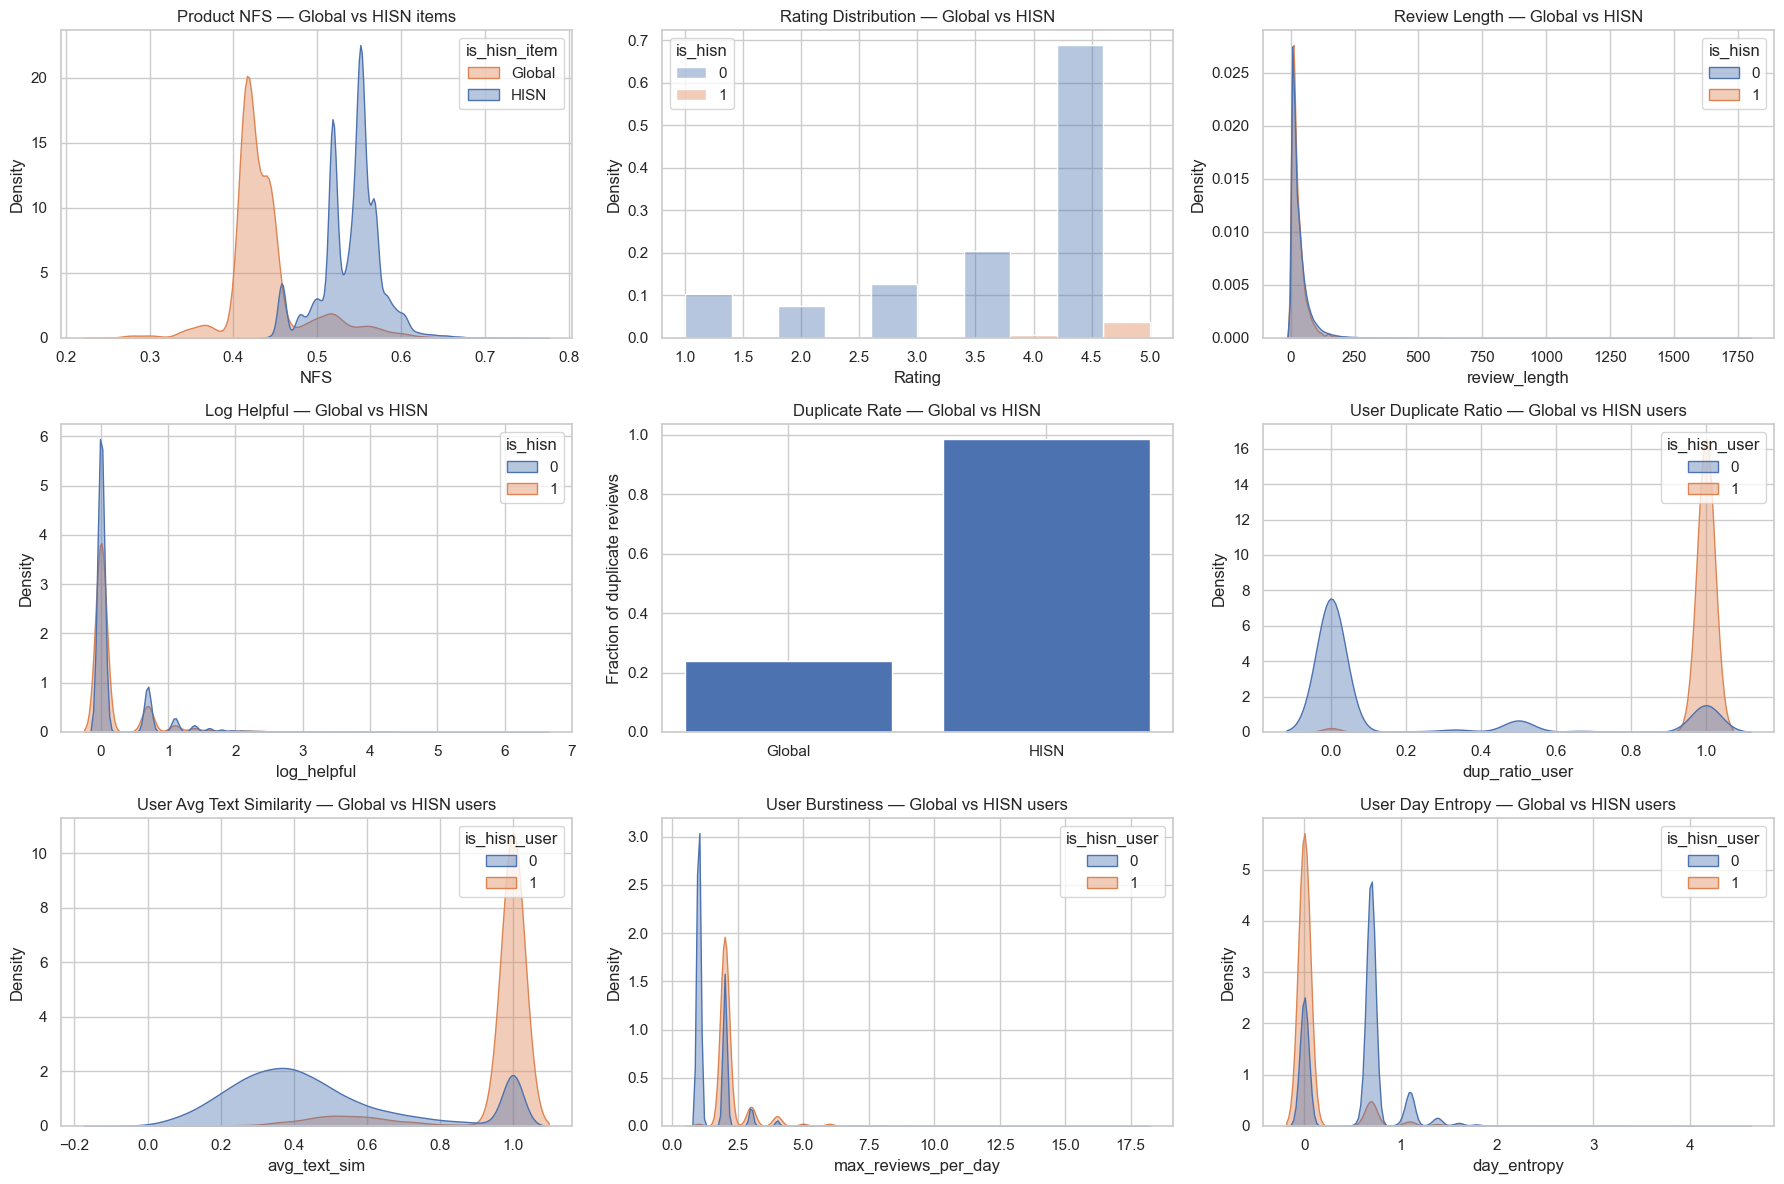

In [73]:
# ==========================================
# 📊 HISN Validation — Global vs HISN
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Prepare review-level comparison: full vs HISN
data_full = data.copy()
data_full["is_hisn"] = 0

hisn_reviews = expanded_data.copy()
hisn_reviews["is_hisn"] = 1

# Align columns for concat (just in case)
common_cols = list(set(data_full.columns).intersection(hisn_reviews.columns))
reviews_all = pd.concat(
    [data_full[common_cols], hisn_reviews[common_cols]],
    axis=0
)

# 2) Prepare product-level comparison: NFS full vs HISN products
hisn_items = hisn_reviews["asin"].unique()
product_df["is_hisn_item"] = product_df["asin"].isin(hisn_items).astype(int)

# 3) Prepare user-level comparison: global vs HISN users
hisn_users = hisn_reviews["user_id"].unique()
user_stats_all = user_stats.copy()
user_stats_all["is_hisn_user"] = user_stats_all["user_id"].isin(hisn_users).astype(int)

# ==========================================
# 📊 Create big grid of comparison plots
# ==========================================

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.ravel()  # flatten for easy indexing
idx = 0

# -------- Product-level: NFS distribution --------
ax = axes[idx]; idx += 1
sns.kdeplot(
    data=product_df,
    x="NFS",
    hue="is_hisn_item",
    ax = ax,
    fill = True,
    alpha = 0.4,
    common_norm=False
)
ax.set_title("Product NFS — Global vs HISN items")
ax.legend(title="is_hisn_item", labels=["Global", "HISN"])

# -------- Review-level: Rating distribution --------
ax = axes[idx]; idx += 1
sns.histplot(
    data=reviews_all,
    x="rating",
    hue="is_hisn",
    stat="density",
    multiple="dodge",
    bins=5,
    ax = ax,
    fill = True,
    alpha = 0.4
)
ax.set_title("Rating Distribution — Global vs HISN")
ax.set_xlabel("Rating")

# -------- Review-level: Review length --------
ax = axes[idx]; idx += 1
sns.kdeplot(
    data=reviews_all,
    x="review_length",
    hue="is_hisn",
    common_norm=False,
    ax = ax,
    fill = True,
    alpha = 0.4
)
ax.set_title("Review Length — Global vs HISN")

# -------- Review-level: log_helpful --------
ax = axes[idx]; idx += 1
sns.kdeplot(
    data=reviews_all,
    x="log_helpful",
    hue="is_hisn",
    common_norm=False,
    ax = ax,
    fill = True,
    alpha = 0.4
)
ax.set_title("Log Helpful — Global vs HISN")

# -------- Review-level: is_duplicate --------
ax = axes[idx]; idx += 1
dup_rates = (
    reviews_all
    .groupby("is_hisn")["is_duplicate"]
    .mean()
    .reset_index()
)
ax.bar(
    ["Global", "HISN"],
    dup_rates["is_duplicate"].values
)
ax.set_title("Duplicate Rate — Global vs HISN")
ax.set_ylabel("Fraction of duplicate reviews")

# -------- User-level: dup_ratio_user --------
ax = axes[idx]; idx += 1
sns.kdeplot(
    data=user_stats_all,
    x="dup_ratio_user",
    hue="is_hisn_user",
    common_norm=False,
    ax = ax,
    fill = True,
    alpha = 0.4
)
ax.set_title("User Duplicate Ratio — Global vs HISN users")

# -------- User-level: avg_text_sim --------
ax = axes[idx]; idx += 1
sns.kdeplot(
    data=user_stats_all,
    x="avg_text_sim",
    hue="is_hisn_user",
    common_norm=False,
    ax = ax,
    fill = True,
    alpha = 0.4
)
ax.set_title("User Avg Text Similarity — Global vs HISN users")

# -------- User-level: max_reviews_per_day --------
ax = axes[idx]; idx += 1
sns.kdeplot(
    data=user_stats_all,
    x="max_reviews_per_day",
    hue="is_hisn_user",
    common_norm=False,
    ax = ax,
    fill = True,
    alpha = 0.4
)
ax.set_title("User Burstiness — Global vs HISN users")

# -------- User-level: day_entropy --------
ax = axes[idx]; idx += 1
sns.kdeplot(
    data=user_stats_all,
    x="day_entropy",
    hue="is_hisn_user",
    common_norm=False,
    ax = ax,
    fill = True,
    alpha = 0.4
)
ax.set_title("User Day Entropy — Global vs HISN users")

plt.tight_layout()
plt.show()



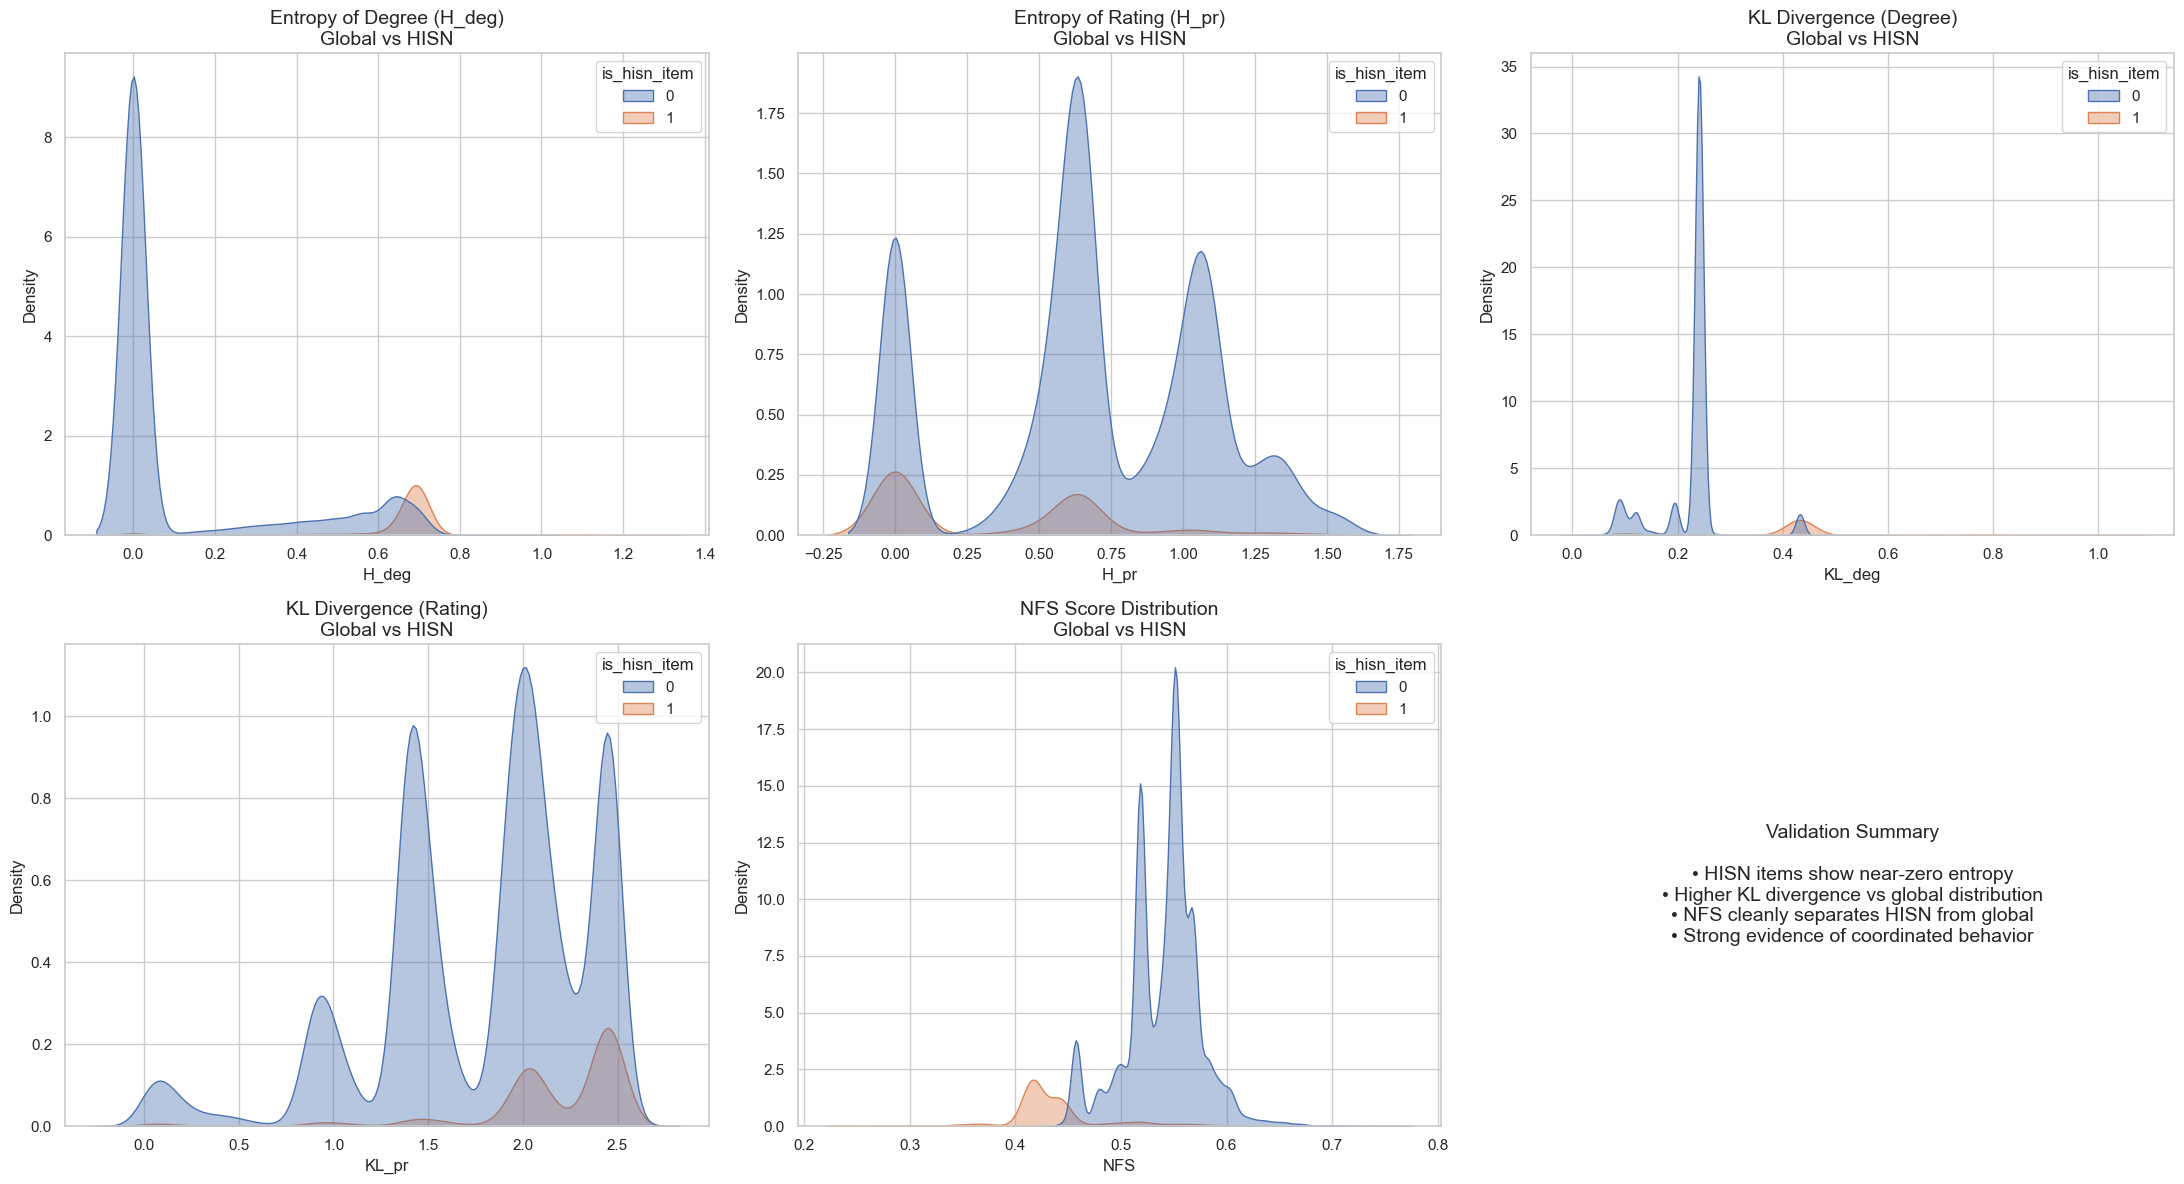

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure setup
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

#---------------#
# 1. H_deg KDE
#---------------#
ax = axes[0, 0]
sns.kdeplot(data=product_df, x="H_deg", hue="is_hisn_item", ax=ax, fill=True, alpha=0.4)
ax.set_title("Entropy of Degree (H_deg)\nGlobal vs HISN", fontsize=14)
ax.set_xlabel("H_deg")
ax.set_ylabel("Density")

#---------------#
# 2. H_pr KDE
#---------------#
ax = axes[0, 1]
sns.kdeplot(data=product_df, x="H_pr", hue="is_hisn_item", ax=ax, fill=True, alpha=0.4)
ax.set_title("Entropy of Rating (H_pr)\nGlobal vs HISN", fontsize=14)
ax.set_xlabel("H_pr")
ax.set_ylabel("Density")

#---------------#
# 3. KL_deg KDE
#---------------#
ax = axes[0, 2]
sns.kdeplot(data=product_df, x="KL_deg", hue="is_hisn_item", ax=ax, fill=True, alpha=0.4)
ax.set_title("KL Divergence (Degree)\nGlobal vs HISN", fontsize=14)
ax.set_xlabel("KL_deg")
ax.set_ylabel("Density")

#---------------#
# 4. KL_pr KDE
#---------------#
ax = axes[1, 0]
sns.kdeplot(data=product_df, x="KL_pr", hue="is_hisn_item", ax=ax, fill=True, alpha=0.4)
ax.set_title("KL Divergence (Rating)\nGlobal vs HISN", fontsize=14)
ax.set_xlabel("KL_pr")
ax.set_ylabel("Density")

#---------------#
# 5. NFS KDE
#---------------#
ax = axes[1, 1]
sns.kdeplot(data=product_df, x="NFS", hue="is_hisn_item", ax=ax, fill=True, alpha=0.4)
ax.set_title("NFS Score Distribution\nGlobal vs HISN", fontsize=14)
ax.set_xlabel("NFS")
ax.set_ylabel("Density")

#---------------#
# 6. Empty panel reserved for explanation or table
#---------------#
axes[1, 2].axis("off")
axes[1, 2].text(
    0.5, 0.5, 
    "Validation Summary\n\n"
    "• HISN items show near-zero entropy\n"
    "• Higher KL divergence vs global distribution\n"
    "• NFS cleanly separates HISN from global\n"
    "• Strong evidence of coordinated behavior",
    ha="center", va="center", fontsize=14
)

plt.tight_layout()
plt.show()


In [74]:
# ==========================================
# 📋 Quick numeric summary for thesis
# ==========================================

print("\n=== Duplicate rate (review-level) ===")
print(dup_rates.replace({"is_hisn": {0: "Global", 1: "HISN"}}))

print("\n=== User-level mean stats (Global vs HISN users) ===")
print(
    user_stats_all.groupby("is_hisn_user")[
        ["dup_ratio_user", "avg_text_sim", "max_reviews_per_day", "day_entropy"]
    ].mean().rename(index={0: "Global", 1: "HISN"})
)


=== Duplicate rate (review-level) ===
  is_hisn  is_duplicate
0  Global      0.237844
1    HISN      0.985769

=== User-level mean stats (Global vs HISN users) ===
              dup_ratio_user  avg_text_sim  max_reviews_per_day  day_entropy
is_hisn_user                                                                
Global              0.196197      0.477764             1.439909     0.560815
HISN                0.986146      0.943058             2.269691     0.094128
